# Gerando o prototipo 1 do modelo de serie temporal de analise preditivo do crescimento da vegetação

## Sobre o dataset (dataset_rodoanel_10k)
O dataset apresenta **10.000 dados** relacionados a temperatura, clima, dados temporais, vegetação e historico de poda, todos mockados.

Nosso alvo e fazer a previsão do crescimento da vegetação em centimetros (cm) utilizando um modelo de analise de série temporal.

Vamos testar em tese 2 tipos de camadas e estilos, um é o LSTM e o outro é o GRU e vamos aprofundar nossa camada usando 2 camadas dense e 1 dropout.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv('/content/dataset_rodoanel_10k.csv')
df.head(10)

,ID_Ponto,Data,Temperatura_Media_C,Precipitacao_Diaria_mm,Umidade_Relativa_Pct,Radiacao_Solar_MJm2,Evapotranspiracao_mm,Qualidade_Ar_IQAr,Emissao_CO2_gm2,NDVI,...,Semana_Ano,Mes,Estacao,Chuva_Acum_7d_mm,Chuva_Acum_15d_mm,Chuva_Acum_30d_mm,Temp_Media_7d_C,Temp_Media_15d_C,Temp_Media_30d_C,Dias_Sem_Chuva
0,RODO_KM_01,2023-01-01,22.2,0.0,60.2,20.7,4.11,34,443.3,0.37,...,52,1,Verão,0.0,0.0,0.0,22.2,22.2,22.2,1
1,RODO_KM_01,2023-01-02,28.3,0.3,46.6,22.8,5.54,34,418.7,0.37,...,1,1,Verão,0.3,0.3,0.3,25.2,25.2,25.2,0
2,RODO_KM_01,2023-01-03,25.5,0.0,59.5,19.0,4.76,40,431.5,0.38,...,1,1,Verão,0.3,0.3,0.3,25.3,25.3,25.3,1
3,RODO_KM_01,2023-01-04,21.6,16.9,58.8,16.4,3.61,35,439.4,0.41,...,1,1,Verão,17.2,17.2,17.2,24.4,24.4,24.4,0
4,RODO_KM_01,2023-01-05,22.2,0.0,65.9,22.8,4.30,38,455.5,0.43,...,1,1,Verão,17.2,17.2,17.2,24.0,24.0,24.0,1
5,RODO_KM_01,2023-01-06,25.5,4.2,53.5,18.7,4.75,30,443.1,0.40,...,1,1,Verão,21.4,21.4,21.4,24.2,24.2,24.2,0
6,RODO_KM_01,2023-01-07,22.3,13.3,63.6,19.4,4.36,37,419.1,0.42,...,1,1,Verão,34.7,34.7,34.7,23.9,23.9,23.9,0
7,RODO_KM_01,2023-01-08,26.3,3.5,59.4,19.5,4.74,34,480.3,0.39,...,1,1,Verão,38.2,38.2,38.2,24.5,24.2,24.2,0
8,RODO_KM_01,2023-01-09,26.7,34.3,69.7,14.1,4.19,36,456.6,0.52,...,2,1,Verão,72.2,72.5,72.5,24.3,24.5,24.5,0
9,RODO_KM_01,2023-01-10,23.9,25.8,66.2,13.7,3.78,33,452.3,0.58,...,2,1,Verão,98.0,98.3,98.3,24.1,24.4,24.4,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10950 entries, 0 to 10949
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID_Ponto                  10950 non-null  object 
 1   Data                      10950 non-null  object 
 2   Temperatura_Media_C       10950 non-null  float64
 3   Precipitacao_Diaria_mm    10950 non-null  float64
 4   Umidade_Relativa_Pct      10950 non-null  float64
 5   Radiacao_Solar_MJm2       10950 non-null  float64
 6   Evapotranspiracao_mm      10950 non-null  float64
 7   Qualidade_Ar_IQAr         10950 non-null  int64  
 8   Emissao_CO2_gm2           10950 non-null  float64
 9   NDVI                      10950 non-null  float64
 10  EVI                       10950 non-null  float64
 11  Umidade_Solo_Pct          10950 non-null  float64
 12  Crescimento_Acumulado_cm  10950 non-null  float64
 13  Crescimento_Semanal_cm    10950 non-null  float64
 14  Cresci

In [5]:
df.describe()

,Temperatura_Media_C,Precipitacao_Diaria_mm,Umidade_Relativa_Pct,Radiacao_Solar_MJm2,Evapotranspiracao_mm,Qualidade_Ar_IQAr,Emissao_CO2_gm2,NDVI,EVI,Umidade_Solo_Pct,...,Dia_Ano,Semana_Ano,Mes,Chuva_Acum_7d_mm,Chuva_Acum_15d_mm,Chuva_Acum_30d_mm,Temp_Media_7d_C,Temp_Media_15d_C,Temp_Media_30d_C,Dias_Sem_Chuva
count,10950.000000,10950.000000,10950.000000,10950.000000,10950.000000,10950.000000,10950.000000,10950.000000,10950.000000,10950.000000,...,10950.00000,10950.000000,10950.000000,10950.000000,10950.000000,10950.000000,10950.000000,10950.000000,10950.000000,10950.000000
mean,20.495689,3.572904,64.901936,17.940922,3.571587,44.134703,452.954785,0.528010,0.343164,16.446521,...,183.00000,26.569863,6.526027,24.722320,52.152420,101.150639,20.492658,20.492712,20.493479,3.055708
std,3.616932,8.606206,4.959769,3.905486,0.850965,13.893855,22.357352,0.116584,0.076402,8.620346,...,105.37084,15.047597,3.448009,24.200802,37.948188,59.631034,2.921089,2.816492,2.712335,4.460316
min,9.900000,0.000000,45.700000,5.000000,0.800000,18.000000,380.200000,0.310000,0.190000,8.000000,...,1.00000,1.000000,1.000000,0.000000,0.000000,0.000000,13.200000,14.700000,15.400000,0.000000
25%,17.900000,0.000000,61.500000,15.400000,2.930000,35.000000,437.500000,0.440000,0.280000,8.900000,...,92.00000,14.000000,4.000000,5.900000,23.300000,57.425000,18.300000,18.400000,18.400000,0.000000
50%,20.400000,0.000000,64.900000,17.500000,3.550000,40.000000,450.900000,0.500000,0.330000,14.200000,...,183.00000,27.000000,7.000000,18.600000,44.900000,94.300000,20.600000,20.500000,20.600000,2.000000
75%,22.900000,1.875000,68.300000,21.300000,4.190000,51.000000,466.275000,0.590000,0.390000,21.100000,...,274.00000,40.000000,10.000000,36.400000,73.175000,136.675000,22.400000,22.300000,22.400000,4.000000
max,33.700000,96.400000,84.600000,26.900000,6.230000,140.000000,562.300000,0.880000,0.600000,50.000000,...,365.00000,52.000000,12.000000,194.700000,254.700000,349.600000,28.900000,28.900000,28.900000,50.000000


### Engenharia de Features


In [6]:
# Ajuste das features data
df['Data'] = pd.to_datetime(df['Data'])
df['Data_Ultima_Poda'] = pd.to_datetime(df['Data_Ultima_Poda'])

# Ajustar o dataframe para ID ponto e data
df = df.sort_values(by=['ID_Ponto', 'Data']).reset_index(drop=True)

# Indexação do data
df = df.set_index('Data')

print('DataFrame Info after initial preprocessing:')
df.info()

# Indentificando variavel alvo (Crescimento_Acumulado_cm)
target_variable = 'Crescimento_Acumulado_cm'
print(f"\nTarget variable identified: {target_variable}")

DataFrame Info after initial preprocessing:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 10950 entries, 2023-01-01 to 2023-12-31
Data columns (total 33 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   ID_Ponto                  10950 non-null  object        
 1   Temperatura_Media_C       10950 non-null  float64       
 2   Precipitacao_Diaria_mm    10950 non-null  float64       
 3   Umidade_Relativa_Pct      10950 non-null  float64       
 4   Radiacao_Solar_MJm2       10950 non-null  float64       
 5   Evapotranspiracao_mm      10950 non-null  float64       
 6   Qualidade_Ar_IQAr         10950 non-null  int64         
 7   Emissao_CO2_gm2           10950 non-null  float64       
 8   NDVI                      10950 non-null  float64       
 9   EVI                       10950 non-null  float64       
 10  Umidade_Solo_Pct          10950 non-null  float64       
 11  Crescimento_Acumula

In [7]:
# Indentificando colunas categoricas para One-Hot_encoding
categorical_cols = [
    'ID_Ponto',
    'Especie_Predominante',
    'Tipo_Solo',
    'Orientacao_Encosta',
    'Intensidade_Ultima_Poda',
    'Estacao'
]

# Display das variaveis categoricas
print('Unique values in categorical columns:')
for col in categorical_cols:
    print(f"{col}: {df[col].unique()}")

# Usando one-hot-encoding
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Display DataFrame info after one-hot encoding
print('\nDataFrame Info after One-Hot Encoding:')
df.info()

print(f"\nNumber of columns after one-hot encoding: {df.shape[1]}")

Unique values in categorical columns:
ID_Ponto: ['RODO_KM_01' 'RODO_KM_02' 'RODO_KM_03' 'RODO_KM_04' 'RODO_KM_05'
 'RODO_KM_06' 'RODO_KM_07' 'RODO_KM_08' 'RODO_KM_09' 'RODO_KM_10'
 'RODO_KM_11' 'RODO_KM_12' 'RODO_KM_13' 'RODO_KM_14' 'RODO_KM_15'
 'RODO_KM_16' 'RODO_KM_17' 'RODO_KM_18' 'RODO_KM_19' 'RODO_KM_20'
 'RODO_KM_21' 'RODO_KM_22' 'RODO_KM_23' 'RODO_KM_24' 'RODO_KM_25'
 'RODO_KM_26' 'RODO_KM_27' 'RODO_KM_28' 'RODO_KM_29' 'RODO_KM_30']
Especie_Predominante: ['Urochloa brizantha' 'Pennisetum purpureum' 'Baccharis dracunculifolia'
 'Melinis minutiflora']
Tipo_Solo: ['Argissolo Vermelho-Amarelo' 'Cambissolo Húmico' 'Latossolo Vermelho']
Orientacao_Encosta: ['Sudoeste' 'Leste' 'Sudeste' 'Oeste' 'Sul' 'Noroeste' 'Nordeste' 'Norte']
Intensidade_Ultima_Poda: ['Severa' 'Moderada' 'Leve']
Estacao: ['Verão' 'Outono' 'Inverno' 'Primavera']

DataFrame Info after One-Hot Encoding:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 10950 entries, 2023-01-01 to 2023-12-31
Data columns (total 7

In [8]:
# Dropando a feature Data_Ultima_Poda ja que Data_desde_poda esta disponivel
df = df.drop('Data_Ultima_Poda', axis=1)

print('DataFrame Info after dropping Data_Ultima_Poda:')
df.info()
print(f"\nNumber of columns after dropping Data_Ultima_Poda: {df.shape[1]}")

DataFrame Info after dropping Data_Ultima_Poda:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 10950 entries, 2023-01-01 to 2023-12-31
Data columns (total 72 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Temperatura_Media_C                        10950 non-null  float64
 1   Precipitacao_Diaria_mm                     10950 non-null  float64
 2   Umidade_Relativa_Pct                       10950 non-null  float64
 3   Radiacao_Solar_MJm2                        10950 non-null  float64
 4   Evapotranspiracao_mm                       10950 non-null  float64
 5   Qualidade_Ar_IQAr                          10950 non-null  int64  
 6   Emissao_CO2_gm2                            10950 non-null  float64
 7   NDVI                                       10950 non-null  float64
 8   EVI                                        10950 non-null  float64
 9   Umidade_Solo_Pct             

### Pré-processamento

In [9]:
# Separação do dataset entre feature e target
features = df.drop(columns=[target_variable])
target = df[[target_variable]]

# MinMax Scaler nas features e targets
scaler_features = MinMaxScaler(feature_range=(0, 1))
scaler_target = MinMaxScaler(feature_range=(0, 1))

# fit e transform nas features
scaled_features = scaler_features.fit_transform(features)
scaled_features_df = pd.DataFrame(scaled_features, columns=features.columns, index=df.index)

# Fit e transform na target
scaled_target = scaler_target.fit_transform(target)
scaled_target_df = pd.DataFrame(scaled_target, columns=target.columns, index=df.index)

print('Shape of scaled features:', scaled_features_df.shape)
print('Shape of scaled target:', scaled_target_df.shape)
print('\nFirst 5 rows of scaled features:')
print(scaled_features_df.head())
print('\nFirst 5 rows of scaled target:')
print(scaled_target_df.head())

Shape of scaled features: (10950, 71)
Shape of scaled target: (10950, 1)

First 5 rows of scaled features:
            Temperatura_Media_C  Precipitacao_Diaria_mm  Umidade_Relativa_Pct  \
Data                                                                            
2023-01-01             0.516807                0.000000              0.372751   
2023-01-02             0.773109                0.003112              0.023136   
2023-01-03             0.655462                0.000000              0.354756   
2023-01-04             0.491597                0.175311              0.336761   
2023-01-05             0.516807                0.000000              0.519280   

            Radiacao_Solar_MJm2  Evapotranspiracao_mm  Qualidade_Ar_IQAr  \
Data                                                                       
2023-01-01             0.716895              0.609576           0.131148   
2023-01-02             0.812785              0.872928           0.131148   
2023-01-03           

In [10]:
def create_sequences(data_df, id_col, target_col, look_back=1):
    Xs, ys = [], []
    unique_ids = data_df[id_col].unique()

    for uid in unique_ids:
        current_id_data = data_df[data_df[id_col] == uid]

        # Extract features and target for the current ID
        # Ensure ID_Ponto and target_col are dropped from features for sequence creation
        current_id_features = current_id_data.drop(columns=[id_col, target_col], errors='ignore')
        current_id_target = current_id_data[[target_col]]

        # Check if there's enough data for the look_back period
        if len(current_id_features) < look_back + 1:
            continue

        for i in range(len(current_id_features) - look_back):
            Xs.append(current_id_features.iloc[i:(i + look_back)].values)
            ys.append(current_id_target.iloc[i + look_back].values)

    return np.array(Xs), np.array(ys)

# Window do modelo
look_back = 20

temp_df = pd.read_csv('/content/dataset_rodoanel_10k.csv')
temp_df['Data'] = pd.to_datetime(temp_df['Data'])
temp_df = temp_df.sort_values(by=['ID_Ponto', 'Data']).reset_index(drop=True)
temp_df = temp_df.set_index('Data')
original_id_ponto_series = temp_df['ID_Ponto']

# Create a combined scaled DataFrame that includes ID_Ponto for robust grouping
full_scaled_df = scaled_features_df.copy()
full_scaled_df[target_variable] = scaled_target_df[target_variable]
# Add the original ID_Ponto series, it should align by index with the rest of full_scaled_df
full_scaled_df['ID_Ponto'] = original_id_ponto_series

# Create sequences using the new function with the combined DataFrame
X, y = create_sequences(full_scaled_df, 'ID_Ponto', target_variable, look_back)

print(f"Shape of X (features sequences): {X.shape}")
print(f"Shape of y (target values): {y.shape}")

# Separação dos dados de treino e de teste 80% e 20%
train_size = int(len(X) * 0.8)
X_train, X_test = X[0:train_size], X[train_size:len(X)]
y_train, y_test = y[0:train_size], y[train_size:len(y)]

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X (features sequences): (10350, 20, 71)
Shape of y (target values): (10350, 1)
Shape of X_train: (8280, 20, 71)
Shape of y_train: (8280, 1)
Shape of X_test: (2070, 20, 71)
Shape of y_test: (2070, 1)


### Criação do modelo

In [11]:
num_features = X_train.shape[2]
look_back = X_train.shape[1]

# --- LSTM Model ---
print("Building LSTM Model...")
lstm_model = Sequential([
    LSTM(units=50, return_sequences=True, input_shape=(look_back, num_features)),
    Dropout(0.2),
    LSTM(units=50, return_sequences=False),
    Dropout(0.2),
    Dense(units=1)  # Output layer for regression
])

lstm_model.compile(optimizer='adam', loss='mean_squared_error')
lstm_model.summary()

# --- GRU Model ---
print("\nBuilding GRU Model...")
gru_model = Sequential([
    GRU(units=50, return_sequences=True, input_shape=(look_back, num_features)),
    Dropout(0.2),
    GRU(units=50, return_sequences=False),
    Dropout(0.2),
    Dense(units=1)
])

gru_model.compile(optimizer='adam', loss='mean_squared_error')
gru_model.summary()

Building LSTM Model...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 20, 50)         │        24,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,651 (174.42 KB)

 Trainable params: 44,651 (174.42 KB)

...

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 20, 50)         │        18,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 20, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 50)             │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,801 (132.04 KB)

 Trainable params: 33,801 (132.04 KB)

 Non-trainable params: 0 (0.00 B)

### Treinamento e avaliação

In [12]:
print("Training LSTM Model...")
history_lstm = lstm_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

print("LSTM Model training complete.")

Training LSTM Model...
Epoch 1/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.0340 - val_loss: 0.0207
Epoch 2/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.0148 - val_loss: 0.0161
Epoch 3/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0114 - val_loss: 0.0180
Epoch 4/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0101 - val_loss: 0.0130
Epoch 5/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 0.0092 - val_loss: 0.0104
Epoch 6/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 0.0086 - val_loss: 0.0081
Epoch 7/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0078 - val_loss: 0.0069
Epoch 8/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0075 - val_loss: 0.0075
Epoch 9/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - loss: 0.0071 - val_loss: 0.0066
Epoch 10/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 0.0066 - val_loss: 0.0066
Epoch 11/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 0.0064 - val_loss: 0.0059
Epoch 12/50
207/20

### Avaliação do Modelo LSTM

In [13]:
# Make predictions on the test set
lstm_predictions = lstm_model.predict(X_test)

# Inverse transform the predictions and actual values to original scale
lstm_predictions_original = scaler_target.inverse_transform(lstm_predictions)
y_test_original = scaler_target.inverse_transform(y_test)

# Calculate evaluation metrics
mse_lstm = mean_squared_error(y_test_original, lstm_predictions_original)
rmse_lstm = np.sqrt(mse_lstm)
mae_lstm = mean_absolute_error(y_test_original, lstm_predictions_original)

print(f"LSTM Model Evaluation:")
print(f"  Mean Squared Error (MSE): {mse_lstm:.4f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_lstm:.4f}")
print(f"  Mean Absolute Error (MAE): {mae_lstm:.4f}")

65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
LSTM Model Evaluation:
  Mean Squared Error (MSE): 105.5492
  Root Mean Squared Error (RMSE): 10.2737
  Mean Absolute Error (MAE): 7.3560


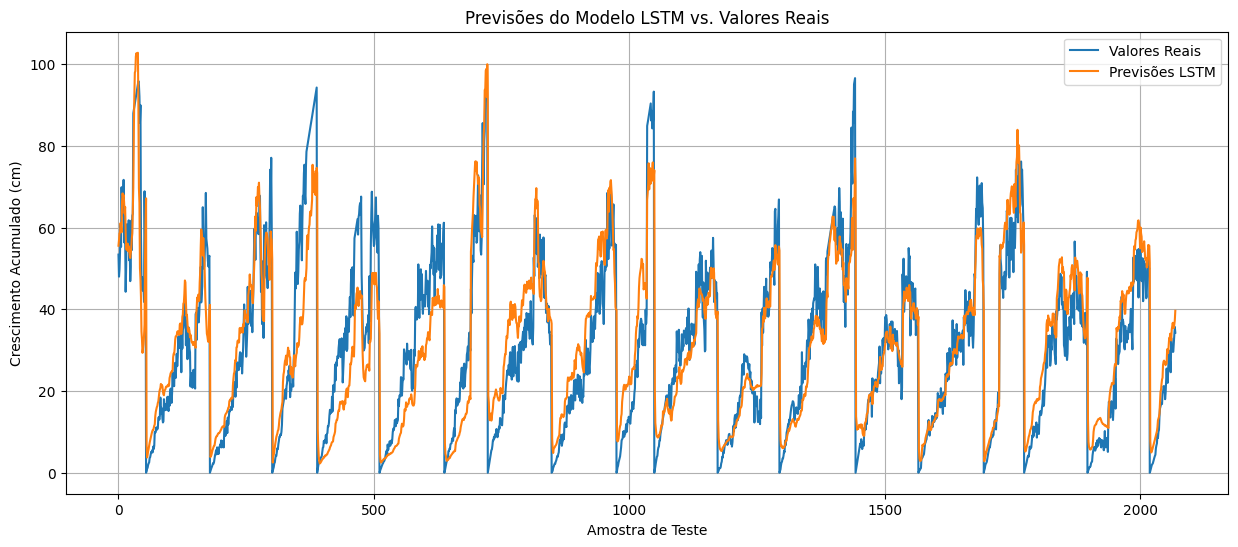

In [14]:
# Visualize LSTM predictions vs actual values
plt.figure(figsize=(15, 6))
plt.plot(y_test_original, label='Valores Reais')
plt.plot(lstm_predictions_original, label='Previsões LSTM')
plt.title('Previsões do Modelo LSTM vs. Valores Reais')
plt.xlabel('Amostra de Teste')
plt.ylabel('Crescimento Acumulado (cm)')
plt.legend()
plt.grid(True)
plt.show()

### Teste final com um dataset menor

In [15]:
df_teste = pd.read_csv('/content/dataset_rodoanel_2k.csv')
df_teste.head(10)

,ID_Ponto,Data,Temperatura_Media_C,Precipitacao_Diaria_mm,Umidade_Relativa_Pct,Radiacao_Solar_MJm2,Evapotranspiracao_mm,Qualidade_Ar_IQAr,Emissao_CO2_gm2,NDVI,...,Semana_Ano,Mes,Estacao,Chuva_Acum_7d_mm,Chuva_Acum_15d_mm,Chuva_Acum_30d_mm,Temp_Media_7d_C,Temp_Media_15d_C,Temp_Media_30d_C,Dias_Sem_Chuva
0,RODO_KM_01,2023-01-01,22.2,0.0,60.2,20.7,4.11,34,443.3,0.37,...,52,1,Verão,0.0,0.0,0.0,22.2,22.2,22.2,1
1,RODO_KM_01,2023-01-02,28.3,0.3,46.6,22.8,5.54,34,418.7,0.37,...,1,1,Verão,0.3,0.3,0.3,25.2,25.2,25.2,0
2,RODO_KM_01,2023-01-03,25.5,0.0,59.5,19.0,4.76,40,431.5,0.38,...,1,1,Verão,0.3,0.3,0.3,25.3,25.3,25.3,1
3,RODO_KM_01,2023-01-04,21.6,16.9,58.8,16.4,3.61,35,439.4,0.41,...,1,1,Verão,17.2,17.2,17.2,24.4,24.4,24.4,0
4,RODO_KM_01,2023-01-05,22.2,0.0,65.9,22.8,4.30,38,455.5,0.43,...,1,1,Verão,17.2,17.2,17.2,24.0,24.0,24.0,1
5,RODO_KM_01,2023-01-06,25.5,4.2,53.5,18.7,4.75,30,443.1,0.40,...,1,1,Verão,21.4,21.4,21.4,24.2,24.2,24.2,0
6,RODO_KM_01,2023-01-07,22.3,13.3,63.6,19.4,4.36,37,419.1,0.42,...,1,1,Verão,34.7,34.7,34.7,23.9,23.9,23.9,0
7,RODO_KM_01,2023-01-08,26.3,3.5,59.4,19.5,4.74,34,480.3,0.39,...,1,1,Verão,38.2,38.2,38.2,24.5,24.2,24.2,0
8,RODO_KM_01,2023-01-09,26.7,34.3,69.7,14.1,4.19,36,456.6,0.52,...,2,1,Verão,72.2,72.5,72.5,24.3,24.5,24.5,0
9,RODO_KM_01,2023-01-10,23.9,25.8,66.2,13.7,3.78,33,452.3,0.58,...,2,1,Verão,98.0,98.3,98.3,24.1,24.4,24.4,0


In [16]:
import matplotlib.pyplot as plt

# 1. Initial preprocessing for df_teste (keeping target variable)
df_teste_processed_full = df_teste.copy()

df_teste_processed_full['Data'] = pd.to_datetime(df_teste_processed_full['Data'])
df_teste_processed_full = df_teste_processed_full.sort_values(by=['ID_Ponto', 'Data']).reset_index(drop=True)
df_teste_processed_full = df_teste_processed_full.set_index('Data')

# Store original ID_Ponto for sequence creation later
original_id_ponto_series_teste_with_target = df_teste_processed_full['ID_Ponto']

# 2. Categorical Feature Encoding (using the same categories as before)
df_teste_processed_full = pd.get_dummies(df_teste_processed_full, columns=categorical_cols, drop_first=True)

# 3. Irrelevant Column Removal
df_teste_processed_full = df_teste_processed_full.drop('Data_Ultima_Poda', axis=1)

# 4. Separate features and target for alignment and scaling
features_for_scaling_teste = df_teste_processed_full.drop(columns=[target_variable])
target_for_scaling_teste = df_teste_processed_full[[target_variable]]

# Align columns for features with training features (add missing, drop extra)
missing_cols_features_for_scaling_teste = set(features.columns) - set(features_for_scaling_teste.columns)
for c in missing_cols_features_for_scaling_teste:
    features_for_scaling_teste[c] = 0
extra_cols_features_for_scaling_teste = set(features_for_scaling_teste.columns) - set(features.columns)
if len(extra_cols_features_for_scaling_teste) > 0:
    features_for_scaling_teste = features_for_scaling_teste.drop(columns=list(extra_cols_features_for_scaling_teste))
features_for_scaling_teste = features_for_scaling_teste[features.columns] # Ensure column order

# 5. Scale features and target using previously fitted scalers
scaled_features_df_teste_final = pd.DataFrame(scaler_features.transform(features_for_scaling_teste),
                                              columns=features.columns,
                                              index=features_for_scaling_teste.index)
scaled_target_df_teste_final = pd.DataFrame(scaler_target.transform(target_for_scaling_teste),
                                            columns=target_for_scaling_teste.columns,
                                            index=target_for_scaling_teste.index)

# 6. Combine scaled features and scaled target with ID_Ponto for sequence creation
full_scaled_df_teste_for_actuals = scaled_features_df_teste_final.copy()
full_scaled_df_teste_for_actuals[target_variable] = scaled_target_df_teste_final[target_variable]
full_scaled_df_teste_for_actuals['ID_Ponto'] = original_id_ponto_series_teste_with_target

print("\nDataFrame de teste (com target) após pré-processamento e alinhamento de colunas:")
print(full_scaled_df_teste_for_actuals.head())
print(f"Shape do DataFrame de teste: {full_scaled_df_teste_for_actuals.shape}")

# 7. Define a function to create sequences for prediction and also capture corresponding dates, IDs, and actual target values
def create_sequences_for_prediction_and_actuals(data_df, id_col, target_col, look_back=1):
    Xs, dates_for_sequences, ids_for_sequences, ys_actual_scaled = [], [], [], []
    unique_ids = data_df[id_col].unique()

    for uid in unique_ids:
        current_id_data = data_df[data_df[id_col] == uid]
        current_id_features = current_id_data.drop(columns=[id_col, target_col], errors='ignore')
        current_id_target_scaled = current_id_data[target_col]
        current_id_dates = current_id_data.index

        if len(current_id_features) < look_back + 1:
            continue

        for i in range(len(current_id_features) - look_back):
            Xs.append(current_id_features.iloc[i:(i + look_back)].values)
            dates_for_sequences.append(current_id_dates[i + look_back])
            ids_for_sequences.append(uid)
            ys_actual_scaled.append(current_id_target_scaled.iloc[i + look_back])

    return np.array(Xs), np.array(dates_for_sequences), np.array(ids_for_sequences), np.array(ys_actual_scaled)

# 8. Create sequences for prediction and get corresponding dates, IDs, and actual target values
X_teste_predict, prediction_dates_actual, prediction_ids_actual, y_teste_actual_scaled = \
    create_sequences_for_prediction_and_actuals(full_scaled_df_teste_for_actuals, 'ID_Ponto', target_variable, look_back)

print(f"\nShape de X_teste_predict (sequências para o dataset de teste): {X_teste_predict.shape}")
print(f"Número de datas para as previsões: {len(prediction_dates_actual)}")
print(f"Número de IDs para as previsões: {len(prediction_ids_actual)}")
print(f"Shape de y_teste_actual_scaled (valores reais escalados): {y_teste_actual_scaled.shape}")

# 9. Make predictions with the trained LSTM model
print("\nGerando previsões com o modelo LSTM para o dataset de teste...")
lstm_predictions_teste_scaled = lstm_model.predict(X_teste_predict)

# 10. Inverse transform predictions to original scale
lstm_predictions_teste_original = scaler_target.inverse_transform(lstm_predictions_teste_scaled)

# 11. Inverse transform actual target values to original scale
y_teste_actual_original = scaler_target.inverse_transform(y_teste_actual_scaled.reshape(-1, 1))

print("\nPrevisões do modelo LSTM para o dataset de teste (Crescimento_Acumulado_cm):")
print(lstm_predictions_teste_original[:5])
print("\nValores reais para o dataset de teste (Crescimento_Acumulado_cm):")
print(y_teste_actual_original[:5])


DataFrame de teste (com target) após pré-processamento e alinhamento de colunas:
            Temperatura_Media_C  Precipitacao_Diaria_mm  Umidade_Relativa_Pct  \
Data                                                                            
2023-01-01             0.516807                0.000000              0.372751   
2023-01-02             0.773109                0.003112              0.023136   
2023-01-03             0.655462                0.000000              0.354756   
2023-01-04             0.491597                0.175311              0.336761   
2023-01-05             0.516807                0.000000              0.519280   

            Radiacao_Solar_MJm2  Evapotranspiracao_mm  Qualidade_Ar_IQAr  \
Data                                                                       
2023-01-01             0.716895              0.609576           0.131148   
2023-01-02             0.812785              0.872928           0.131148   
2023-01-03             0.639269              0

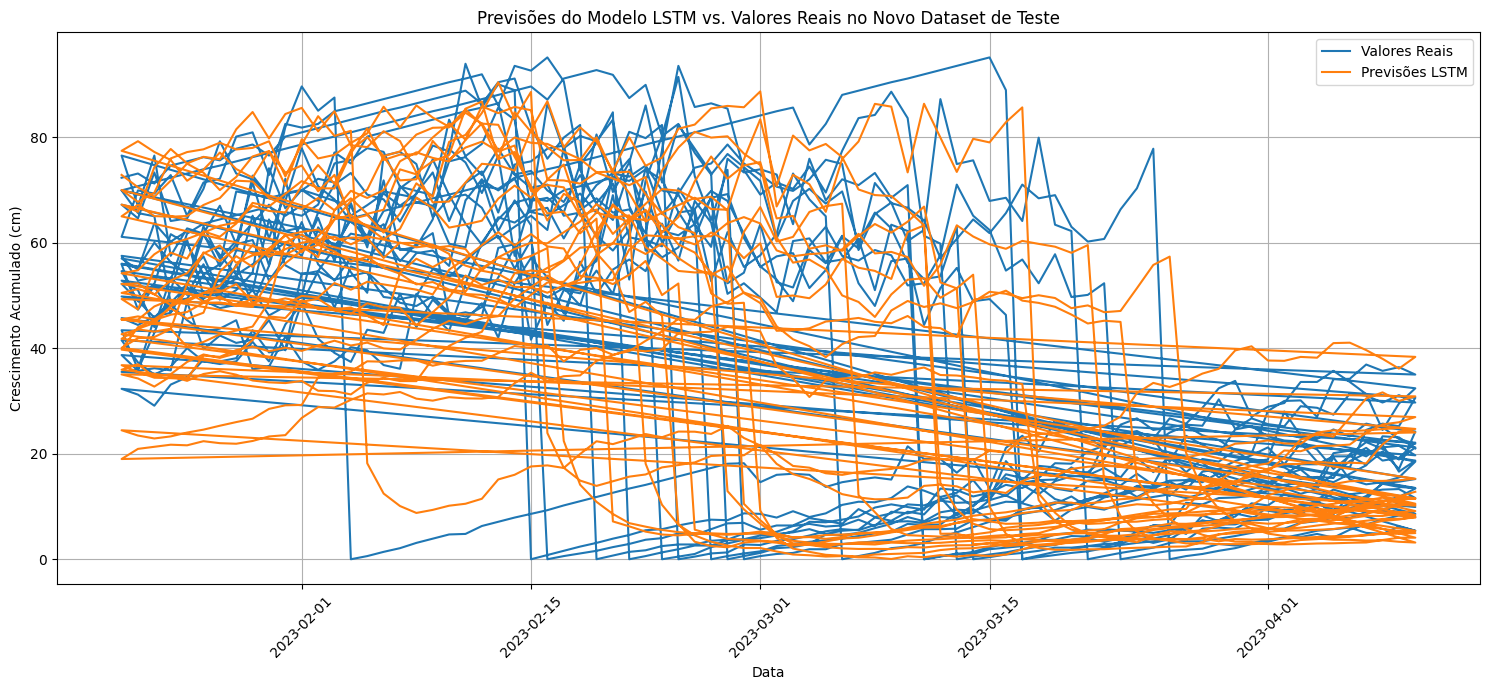

In [17]:
import matplotlib.pyplot as plt

# Visualize LSTM predictions vs actual values on the test dataset
plt.figure(figsize=(15, 7))
plt.plot(prediction_dates_actual, y_teste_actual_original, label='Valores Reais')
plt.plot(prediction_dates_actual, lstm_predictions_teste_original, label='Previsões LSTM')
plt.title('Previsões do Modelo LSTM vs. Valores Reais no Novo Dataset de Teste')
plt.xlabel('Data')
plt.ylabel('Crescimento Acumulado (cm)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
from sklearn.metrics import mean_absolute_error

# Calculate MAE for the new test dataset predictions
mae_teste = mean_absolute_error(y_teste_actual_original, lstm_predictions_teste_original)

print(f"Mean Absolute Error (MAE) for the new test dataset: {mae_teste:.4f}")

Mean Absolute Error (MAE) for the new test dataset: 8.4385


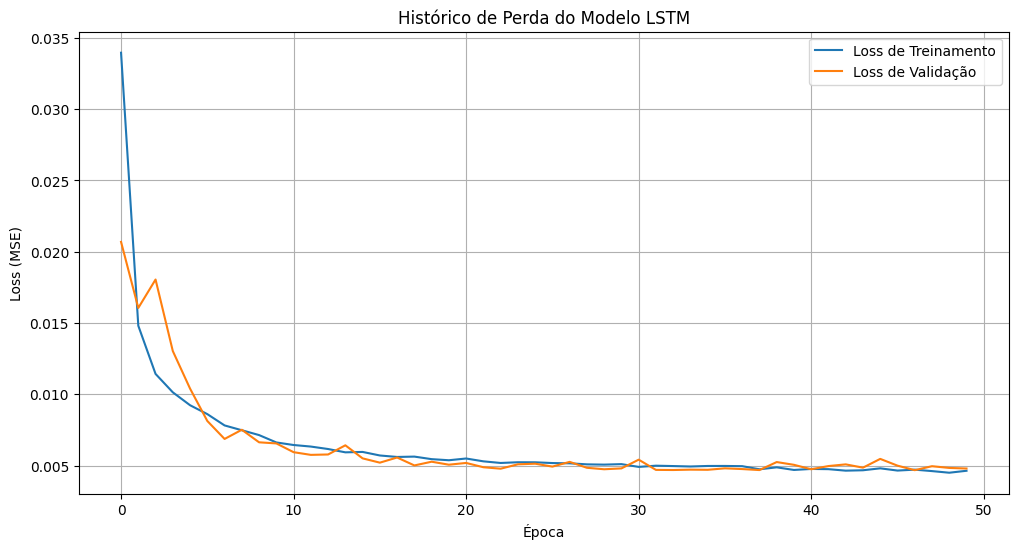

In [19]:
import matplotlib.pyplot as plt

# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history_lstm.history['loss'], label='Loss de Treinamento')
plt.plot(history_lstm.history['val_loss'], label='Loss de Validação')
plt.title('Histórico de Perda do Modelo LSTM')
plt.xlabel('Época')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

### Conclusão do modelo LSTM
No Primeiro teste, obtivemos uma media de erro absoluto (MEA ou MAE em ingles) de **7.506**, a possivel causa desse valor se deve a certos erros:
1. Possivel **OverLifting ou UnderLifting**
2. Valor de **Window** (look_back) baixo
3. Modelo muito **Simplificado ou muito complexo**
4. **Hyperparametros** com uma eficiencia muito baixa

### Possiveis soluções
1. Early Stopping
2. Ajuste de hyperparametros
3. Equilibrar a complexidade do modelo

In [20]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 7.0 MB/s eta 0:00:00


In [21]:
import keras_tuner as kt

def build_lstm_model(hp):
    model = Sequential()
    # Tune the number of LSTM units in the first layer
    hp_units_1 = hp.Int('units_1', min_value=32, max_value=128, step=16)
    model.add(LSTM(units=hp_units_1, return_sequences=True, input_shape=(look_back, num_features)))
    # Tune the dropout rate for the first dropout layer
    hp_dropout_1 = hp.Float('dropout_1', min_value=0.1, max_value=0.5, step=0.1)
    model.add(Dropout(hp_dropout_1))

    # Tune the number of LSTM units in the second layer
    hp_units_2 = hp.Int('units_2', min_value=32, max_value=128, step=16)
    model.add(LSTM(units=hp_units_2, return_sequences=False))
    # Tune the dropout rate for the second dropout layer
    hp_dropout_2 = hp.Float('dropout_2', min_value=0.1, max_value=0.5, step=0.1)
    model.add(Dropout(hp_dropout_2))

    model.add(Dense(units=1))

    # Tune the learning rate for the optimizer
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    optimizer = tf.keras.optimizers.Adam(learning_rate=hp_learning_rate)

    model.compile(optimizer=optimizer, loss='mean_squared_error')
    return model

tuner = kt.RandomSearch(
    build_lstm_model,
    objective='val_loss',
    max_trials=10,  # Number of hyperparameter combinations to try
    executions_per_trial=1,  # Number of models to train for each trial
    directory='keras_tuner_dir', # Directory to store results
    project_name='lstm_hyperparameter_tuning')

print("Starting hyperparameter search...")
# Use a subset of data or fewer epochs for faster tuning if needed
tuner.search(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=1)

print("Hyperparameter search complete.")

# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"\nOptimal LSTM units for first layer: {best_hps.get('units_1')}")
print(f"Optimal dropout rate for first layer: {best_hps.get('dropout_1')}")
print(f"Optimal LSTM units for second layer: {best_hps.get('units_2')}")
print(f"Optimal dropout rate for second layer: {best_hps.get('dropout_2')}")
print(f"Optimal learning rate for the optimizer: {best_hps.get('learning_rate')}")

# Build the best model found by the tuner
best_lstm_model = tuner.get_best_models(num_models=1)[0]

print("\nSummary of the best LSTM model:")
best_lstm_model.summary()

Trial 10 Complete [00h 00m 57s]
val_loss: 0.007963714189827442

Best val_loss So Far: 0.004901505541056395
Total elapsed time: 00h 14m 23s
Hyperparameter search complete.

Optimal LSTM units for first layer: 128
Optimal dropout rate for first layer: 0.2
Optimal LSTM units for second layer: 112
Optimal dropout rate for second layer: 0.30000000000000004
Optimal learning rate for the optimizer: 0.01

Summary of the best LSTM model:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 20, 128)        │       102,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 112)            │       107,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 112)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           113 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 210,481 (822.19 KB)

 Trainable params: 210,481 (822.19 KB)

 Non-trainable params: 0 (0.00 B)

### Avaliação do Modelo LSTM com Hiperparâmetros Ajustados

In [22]:
print("Making predictions with the best LSTM model...")
# Make predictions on the test set using the best model
best_lstm_predictions = best_lstm_model.predict(X_test)

# Inverse transform the predictions and actual values to original scale
best_lstm_predictions_original = scaler_target.inverse_transform(best_lstm_predictions)
# y_test_original was already calculated previously, assuming it's available.
# If not, it would be:
# y_test_original = scaler_target.inverse_transform(y_test)

# Calculate evaluation metrics for the best model
mse_best_lstm = mean_squared_error(y_test_original, best_lstm_predictions_original)
rmse_best_lstm = np.sqrt(mse_best_lstm)
mae_best_lstm = mean_absolute_error(y_test_original, best_lstm_predictions_original)

print(f"\nBest LSTM Model Evaluation:")
print(f"  Mean Squared Error (MSE): {mse_best_lstm:.4f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_best_lstm:.4f}")
print(f"  Mean Absolute Error (MAE): {mae_best_lstm:.4f}")

Making predictions with the best LSTM model...
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step

Best LSTM Model Evaluation:
  Mean Squared Error (MSE): 63.6462
  Root Mean Squared Error (RMSE): 7.9779
  Mean Absolute Error (MAE): 4.8911


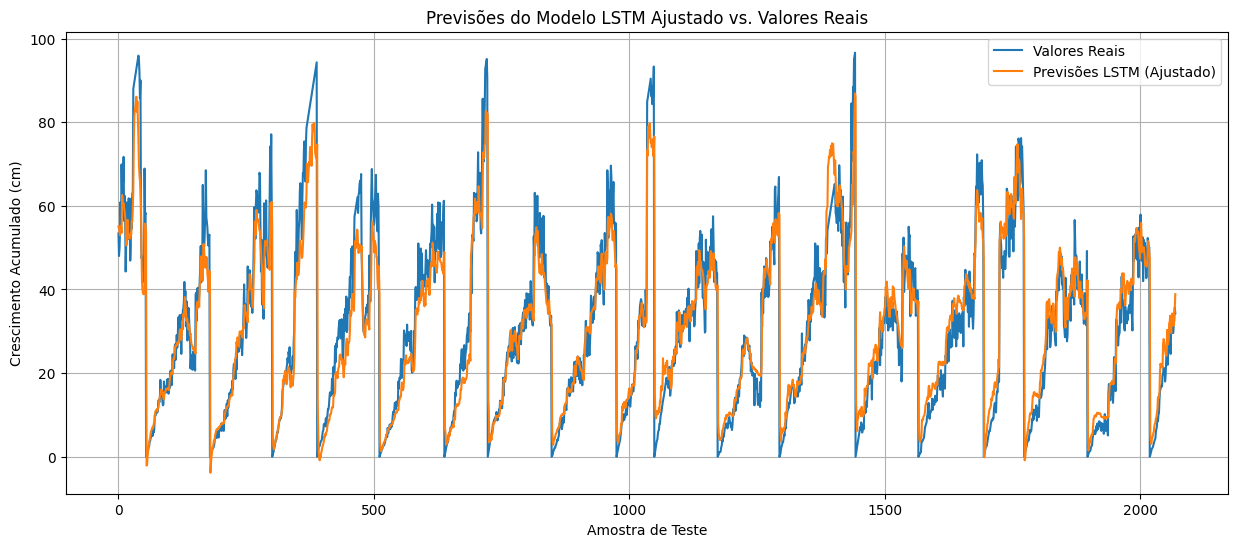

In [23]:
# Visualize predictions vs actual values for the best LSTM model
plt.figure(figsize=(15, 6))
plt.plot(y_test_original, label='Valores Reais')
plt.plot(best_lstm_predictions_original, label='Previsões LSTM (Ajustado)')
plt.title('Previsões do Modelo LSTM Ajustado vs. Valores Reais')
plt.xlabel('Amostra de Teste')
plt.ylabel('Crescimento Acumulado (cm)')
plt.legend()
plt.grid(True)
plt.show()

### Conclusão
Com o ajuste dos hiperparametros chegamos a um valor de 4.89cm de média de erro absoluto, um valor muito melhor do que a do modelo anterior.

O modelo ajustado apresenta 2 camadas LSTM, 2 Dropouts e 1 Dense, com uma curva de aprendizado para 0.01 e com os valores de dropout ajustados para o melhor valor.
